# Synchronization of a single spin ensemble in cavity QED

This simulation is based on the work from Bihui [Synchronization of Interacting Quantum Dipoles](https://arxiv.org/pdf/1502.06055). The dynamics of spins can be (approximately) mapped to a classical Kuramoto model,
$$
\frac{d \phi_a}{d t}=\delta_a+K \sum_{b=1}^N \sin \left[\delta \phi_{b a}\right]
$$
where $K$ is the coupling strength. As $K$ becomes large enough, the system has a synchronization solution, with an order parameter defined as
$$
r e^{i \psi}=\frac{1}{N} \sum_{j=1}^N e^{i \theta_j}.
$$
This order parameter makes sense cause it represents the "mean" oscillating vector of the system. In that paper, the essence of obtaining the steady synchronization is the **collective decay and the indivisual incoherent pump**. The equations of motion read
$$
\begin{aligned}
\frac{\mathrm{d} S_a^z(t)}{\mathrm{d} t}= & -S_a^{\perp}(t) \sum_{b \neq a}^N S_b^{\perp}(t)f \cos (\phi_b-\phi_a)  -\Gamma\left[\frac{1}{2}+S_a^z(t)\right]+W\left[\frac{1}{2}-S_a^z(t)\right] \\
\frac{\mathrm{d} S_a^{\perp}(t)}{\mathrm{d} t}= & -S_a^z(t) \sum_{b \neq a} S_b^{\perp}(t)\left[-f\cos(\phi_b-\phi_a)\right]-\frac{\Gamma+W}{2} S_a^{\perp}(t)\\
\frac{\mathrm{d} \varphi_a(t)}{\mathrm{d} t}=&\delta_a+\sum_{b \neq a}^N S_a^z \frac{S_b^{\perp}}{S_a^{\perp}}\left[f \sin (\phi_b-\phi_a)\right],
\end{aligned}
$$

The signs in front of $W$ and $\Gamma$ are opposite in the equation of motion for $S_a^z$ since they corresponds to dissipation and gain, respectively. However, in the equation for $S_a^\perp$ they become the same, because both the jump operators results in decoherence in the $S_a^\perp$ direction.

### Without inhomogeneity

Before proceeding, it would be easier to use such identity:
$$
\sum_{b} S_b^\perp \cos(\phi_b-\phi_a)=\cos\phi_a \sum_b S_b^x + \sin\phi_a \sum_b S_b^y\\
\sum_{b} S_b^\perp \sin(\phi_b-\phi_a)=\cos\phi_a \sum_b S_b^y - \sin\phi_a \sum_b S_b^x
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

N = 200        
f = 50        # collective dissipation f
Gamma = 1.0    # individual dissipation 
W = 20        # incoherent pump
t_max = 30.0   # evolution time

# Initialize the system
np.random.seed(42) # fixed seed
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)
Sz_init = 0.5 * np.cos(theta_init)
Sperp_init = 0.5 * np.sin(theta_init)

y0 = np.concatenate([Sz_init, Sperp_init, phi_init])


# Solving dynamics by ODE
def spin_dynamics(t, y, N, f, Gamma, W):
    
#The spin values and derivatives are stored in a list
    Sz = y[0:N]
    Sperp = y[N:2*N]
    phi = y[2*N:3*N]
    
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    # Define Sigma_c = sum_{b \neq a} S_b^\perp cos(phi_b - phi_a), where we already used the above identity
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    # Define Sigma_s = sum_{b \neq a} S_b^\perp sin(phi_b - phi_a)
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # derivative
    dSz_dt = -(f / N) * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_dt = (f / N) * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    # prevent divergence as Sperp -> 0
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    dphi_dt = (f / N) * (Sz / Sperp_safe) * Sigma_s
    
    return np.concatenate([dSz_dt, dSperp_dt, dphi_dt])


# Solving ODE
print(f" {N} spins，evolution time t={t_max}...")
sol = solve_ivp(spin_dynamics, [0, t_max], y0, args=(N, f, Gamma, W), 
                method='RK45', t_eval=np.linspace(0, t_max, 500))

# Final state of spins
Sz_final = sol.y[0:N, -1]
Sperp_final = sol.y[N:2*N, -1]
phi_final = sol.y[2*N:3*N, -1]

# Order Parameter 
order_param_complex = np.mean(Sperp_final * np.exp(1j * phi_final))
Z = np.abs(order_param_complex)
Phi = np.angle(order_param_complex)

print("-" * 30)
print(f"Order parameter Z: {Z:.4f}")
print(f"Phase \Phi: {Phi:.4f} rad")
print("-" * 30)



<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


 200 spins，evolution time t=30.0...
------------------------------
Order parameter Z: 0.3192
Phase \Phi: -1.4602 rad
------------------------------


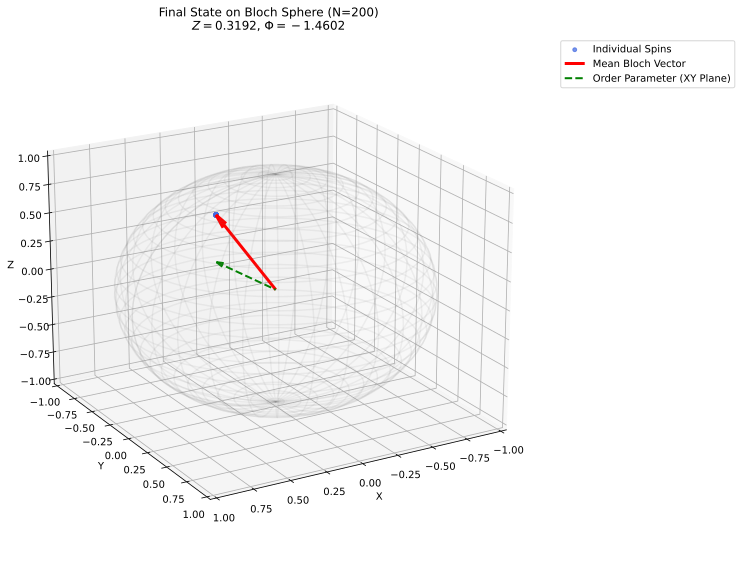

In [2]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)


x_final = 2 * Sperp_final * np.cos(phi_final)
y_final = 2 * Sperp_final * np.sin(phi_final)
z_final = 2 * Sz_final

# visualize individual spins 
ax.scatter(x_final, y_final, z_final, color='royalblue', s=15, alpha=0.7, label='Individual Spins')

# visualize mean Bloch vector
mean_z = 2 * np.mean(Sz_final)
mean_x = 2 * Z * np.cos(Phi)
mean_y = 2 * Z * np.sin(Phi)
ax.quiver(0, 0, 0, mean_x, mean_y, mean_z, color='red', linewidth=3, 
          arrow_length_ratio=0.15, label='Mean Bloch Vector')

# Order Parameter Z
ax.quiver(0, 0, 0, mean_x, mean_y, 0, color='green', linestyle='dashed', linewidth=2, 
          arrow_length_ratio=0.15, label='Order Parameter (XY Plane)')


ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Final State on Bloch Sphere (N={N})\n$Z = {Z:.4f}$, $\Phi = {Phi:.4f}$')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.view_init(elev=20, azim=60) # 

plt.tight_layout()
plt.show()

One can verify that changing $t$ does not affect the value of order parameter, meaning we already entered the 

### With inhomogeneity $\delta$

In [3]:
N = 200        
f = 20        # collective dissipation f
Gamma = 1.0    # individual dissipation 
W = 5.0        # incoherent pump
t_max = 30.0   # evolution time


Delta_disorder = 0.5 # detuning disorder

# Initialize the system
np.random.seed(42)  
delta_a = np.random.normal(0, Delta_disorder, N)
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)
Sz_init = 0.5 * np.cos(theta_init)
Sperp_init = 0.5 * np.sin(theta_init)

y0 = np.concatenate([Sz_init, Sperp_init, phi_init])


# Solving dynamics by ODE
def spin_dynamics(t, y, N, f, Gamma, W):
    
#The spin values and derivatives are stored in a list
    Sz = y[0:N]
    Sperp = y[N:2*N]
    phi = y[2*N:3*N]
    
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    # Define Sigma_c = sum_{b \neq a} S_b^\perp cos(phi_b - phi_a), where we already used the above identity
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    # Define Sigma_s = sum_{b \neq a} S_b^\perp sin(phi_b - phi_a)
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # derivative
    dSz_dt = -(f / N) * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_dt = (f / N) * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    # prevent divergence as Sperp -> 0
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    dphi_dt = delta_a + (f / N) * (Sz / Sperp_safe) * Sigma_s
    
    return np.concatenate([dSz_dt, dSperp_dt, dphi_dt])


# Solving ODE
print(f" {N} spins，evolution time t={t_max}...")
sol = solve_ivp(spin_dynamics, [0, t_max], y0, args=(N, f, Gamma, W), 
                method='RK45', t_eval=np.linspace(0, t_max, 500))

# Final state of spins
Sz_final = sol.y[0:N, -1]
Sperp_final = sol.y[N:2*N, -1]
phi_final = sol.y[2*N:3*N, -1]

# Order Parameter 
order_param_complex = np.mean(Sperp_final * np.exp(1j * phi_final))
Z = np.abs(order_param_complex)
Phi = np.angle(order_param_complex)

print("-" * 30)
print(f"Order parameter Z: {Z:.4f}")
print(f"Phase \Phi: {Phi:.4f} rad")
print("-" * 30)

 200 spins，evolution time t=30.0...
------------------------------
Order parameter Z: 0.2324
Phase \Phi: 0.7978 rad
------------------------------


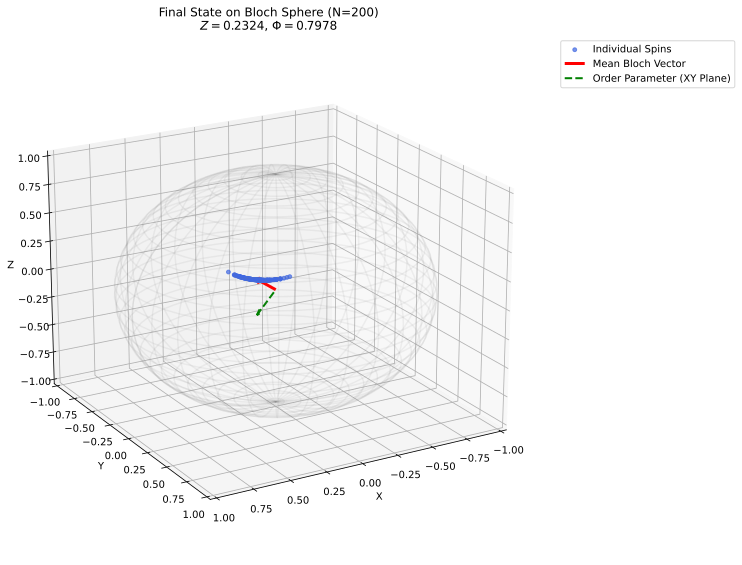

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)


x_final = 2 * Sperp_final * np.cos(phi_final)
y_final = 2 * Sperp_final * np.sin(phi_final)
z_final = 2 * Sz_final

# visualize individual spins 
ax.scatter(x_final, y_final, z_final, color='royalblue', s=15, alpha=0.7, label='Individual Spins')

# visualize mean Bloch vector
mean_z = 2 * np.mean(Sz_final)
mean_x = 2 * Z * np.cos(Phi)
mean_y = 2 * Z * np.sin(Phi)
ax.quiver(0, 0, 0, mean_x, mean_y, mean_z, color='red', linewidth=3, 
          arrow_length_ratio=0.15, label='Mean Bloch Vector')

# Order Parameter Z
ax.quiver(0, 0, 0, mean_x, mean_y, 0, color='green', linestyle='dashed', linewidth=2, 
          arrow_length_ratio=0.15, label='Order Parameter (XY Plane)')


ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Final State on Bloch Sphere (N={N})\n$Z = {Z:.4f}$, $\Phi = {Phi:.4f}$')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.view_init(elev=20, azim=60) # 

plt.tight_layout()
plt.show()

### A single experiment (trajectory) with continuous measurement 

In [5]:
import numpy as np
import matplotlib.pyplot as plt


N = 70
Gamma = 1.0
W = 20.0        
f_eff = 50.0
f = f_eff / N
noise_strength = 0.15 # noise for stochastic differential equation


np.random.seed(42)
u = np.random.uniform(0, 1, N)
theta_init = np.arccos(1 - 2 * u)
phi_init = np.random.uniform(0, 2 * np.pi, N)

Sz = 0.5 * np.cos(theta_init)
Sperp = 0.5 * np.sin(theta_init)
phi = phi_init

# --- 3. Stochastic differential equation ---
dt = 0.01
steps = 3000

for _ in range(steps):
    X = np.sum(Sperp * np.cos(phi))
    Y = np.sum(Sperp * np.sin(phi))
    
    Sigma_c = X * np.cos(phi) + Y * np.sin(phi) - Sperp
    Sigma_s = Y * np.cos(phi) - X * np.sin(phi)
    
    # determinstic drift
    dSz_det = -f * Sperp * Sigma_c - Gamma * (0.5 + Sz) + W * (0.5 - Sz)
    dSperp_det = f * Sz * Sigma_c - 0.5 * (Gamma + W) * Sperp
    Sperp_safe = np.where(Sperp < 1e-12, 1e-12, Sperp)
    dphi_det = f * (Sz / Sperp_safe) * Sigma_s
    
    # noise term
    noise_Sz = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    noise_Sperp = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    noise_phi = np.random.normal(0, np.sqrt(dt) * noise_strength, N)
    
    # updating the state without normalization
    temp_Sz = Sz + dSz_det * dt + noise_Sz
    temp_Sperp = Sperp + dSperp_det * dt + noise_Sperp
    temp_phi = phi + dphi_det * dt + noise_phi
    
    Sz = temp_Sz
    
    Sperp = np.abs(temp_Sperp)
    phi = np.where(temp_Sperp < 0, temp_phi + np.pi, temp_phi)
    phi = (phi + np.pi) % (2 * np.pi) - np.pi

# --- Order Parameter ---
order_param = np.mean(Sperp * np.exp(1j * phi))
Z_val = np.abs(order_param)
Phi = np.angle(order_param)

print(f"Z_max ~= {1/np.sqrt(8):.4f}")
print(f"current Z = {Z_val:.4f}")

Z_max ~= 0.3536
current Z = 0.3232


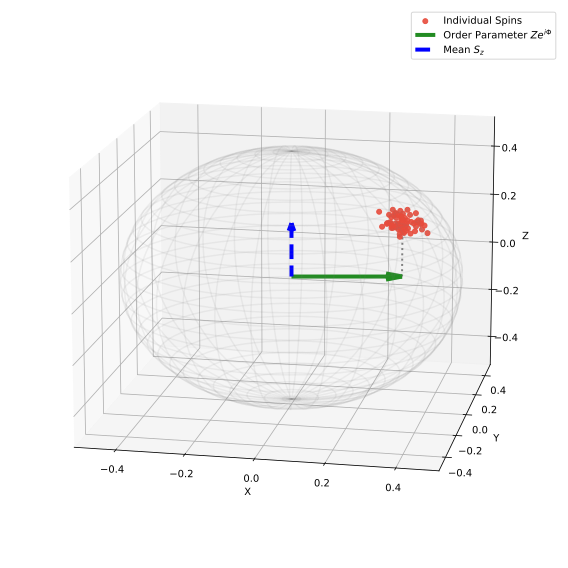

In [6]:
x_final = Sperp * np.cos(phi)
y_final = Sperp * np.sin(phi)
z_final = Sz

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


r = 0.5
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 60)
x_sphere = r * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_sphere = r * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_sphere = r * np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="gray", alpha=0.1)

# Individual Spins: they are inside of the Bloch sphere
ax.scatter(x_final, y_final, z_final, color='#e74c3c', s=25, alpha=0.9, label='Individual Spins')

# Order Parameter 
x_op = Z_val * np.cos(Phi)
y_op = Z_val * np.sin(Phi)
ax.quiver(0, 0, 0, x_op, y_op, 0, color='forestgreen', arrow_length_ratio=0.15, linewidth=4, label=r'Order Parameter $Z e^{i\Phi}$')

# 3. mean spin-z
z_mean = np.mean(z_final)
ax.quiver(0, 0, 0, 0, 0, z_mean, color='blue', linestyle='dashed', arrow_length_ratio=0.15, linewidth=4, label=r'Mean $S_z$')


x_mean = np.mean(x_final)
y_mean = np.mean(y_final)
ax.plot([x_mean, x_mean], [y_mean, y_mean], [0, z_mean], color='gray', linestyle=':', linewidth=2)

ax.set_xlim([-r, r]); ax.set_ylim([-r, r]); ax.set_zlim([-r, r])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=15, azim=Phi*180/np.pi - 90)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()